# Scikit-Learn Pipelines for Clustering

### Dataset: Digits

We'll use the **Digits dataset** from scikit-learn, which contains images of handwritten digits (0-9). Each image is 8×8 pixels, represented as 64 features (pixel intensities).

**The challenge**: Can K-Means discover the 10 digit classes without ever seeing labels?

## 1. Import Required Libraries

We'll need tools for data loading, preprocessing, clustering, evaluation, and visualization.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

# Scikit-learn imports
from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

# Clustering evaluation metrics
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    calinski_harabasz_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score
)

# Visualization settings
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

## 2. Load and Explore the Digits Dataset

The **Digits dataset** contains 1,797 images of handwritten digits (0-9), each represented as an 8×8 pixel grid (64 features total). Each pixel value ranges from 0 (white) to 16 (black).

### Dataset Characteristics

- **Samples**: 1,797 handwritten digit images
- **Features**: 64 (8×8 pixel intensities)
- **Classes**: 10 (digits 0-9)
- **Feature range**: 0-16 (grayscale intensity)

**Important**: Although this dataset has labels, we'll use them ONLY for evaluation. The clustering algorithm will not see the labels during training (that's what makes it **unsupervised**!).

Dataset shape: 1,797 images, 64 features (8×8 pixels)
Classes: 10 digits (0-9)
Feature range: [0, 16] (pixel intensity)


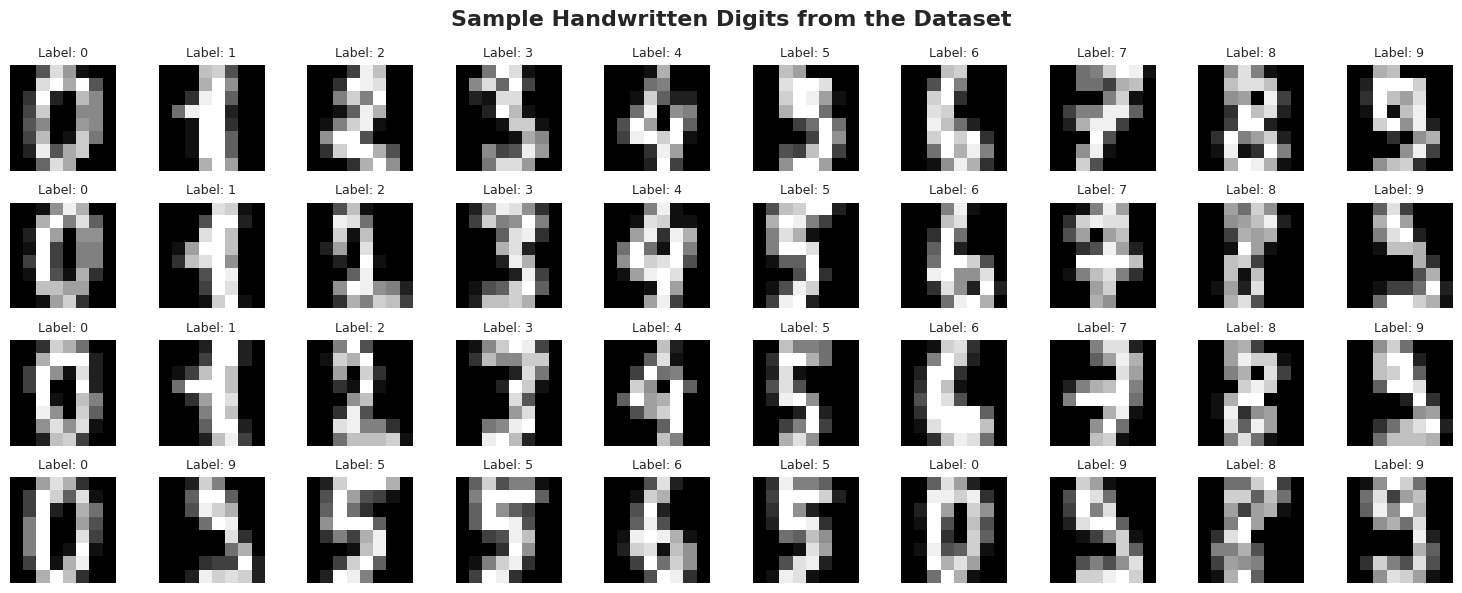

In [ ]:
digits = load_digits() # Load the Digits dataset
X = digits.data  # 64 features (8x8 pixels)
y_true = digits.target  # True labels (for evaluation only!)

print(f"Dataset shape: {X.shape[0]:,} images, {X.shape[1]} features (8×8 pixels)")
print(f"Classes: {len(np.unique(y_true))} digits (0-9)")
print(f"Feature range: [{X.min():.0f}, {X.max():.0f}] (pixel intensity)")

# Visualize sample digits
fig, axes = plt.subplots(4, 10, figsize=(15, 6))
fig.suptitle('Sample Handwritten Digits from the Dataset', fontsize=16, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(X):
        # Reshape 64 features back to 8x8 image
        image = X[i].reshape(8, 8)
        ax.imshow(image, cmap='gray')
        ax.set_title(f'Label: {y_true[i]}', fontsize=9)
    ax.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Display the distribution of samples across the 10 digit classes
unique_classes, class_counts = np.unique(y_true, return_counts=True)

print("Distribution of samples per digit class:")
print(f"{'Digit':<8} {'Count':>8} {'Percentage':>12}")
print("-" * 30)

for digit, count in zip(unique_classes, class_counts):
    percentage = (count / len(y_true)) * 100
    bar = '█' * (count // 10)
    print(f"{digit:<8} {count:>8} ({percentage:>6.2f}%)  {bar}")

print("-" * 30)
print(f"{'Total':<8} {len(y_true):>8} ({100.0:>6.2f}%)")

Distribution of samples per digit class:
Digit       Count   Percentage
------------------------------
0             178 (  9.91%)  █████████████████
1             182 ( 10.13%)  ██████████████████
2             177 (  9.85%)  █████████████████
3             183 ( 10.18%)  ██████████████████
4             181 ( 10.07%)  ██████████████████
5             182 ( 10.13%)  ██████████████████
6             181 ( 10.07%)  ██████████████████
7             179 (  9.96%)  █████████████████
8             174 (  9.68%)  █████████████████
9             180 ( 10.02%)  ██████████████████
------------------------------
Total        1797 (100.00%)


### Feature Scaling Demonstration

Before proceeding with clustering, we analyze the effect of feature scaling. K-Means relies on distance calculations (Euclidean distance), so it is critical that all features contribute equally.

In the following cell, we:
1. Select a few example features (pixels).
2. Compute and display their statistics (Mean, Std, Min, Max) **before scaling**, observing that raw pixel values can vary significantly.
3. Apply `StandardScaler` to transform the data.
4. Compute statistics **after scaling**, confirming that all features now have mean $\approx$ 0 and standard deviation $\approx$ 1.
5. Visualize the distributions using boxplots to verify the normalization.


BEFORE SCALING (Original Features):
Feature          Mean      Std      Min      Max
------------------------------------------------
Pixel 0          0.00     0.00     0.00     0.00
Pixel 20         7.10     6.17     0.00    16.00
Pixel 40         0.01     0.15     0.00     4.00
Pixel 60        11.81     4.93     0.00    16.00

AFTER SCALING (Standardized Features):
Feature          Mean      Std      Min      Max
------------------------------------------------
Pixel 0       0.00000  0.00000     0.00     0.00
Pixel 20      0.00000  1.00000    -1.15     1.44
Pixel 40     -0.00000  1.00000    -0.06    27.50
Pixel 60      0.00000  1.00000    -2.39     0.85

✓ All features now have mean ≈ 0 and std ≈ 1
✓ All features contribute equally to distance calculations


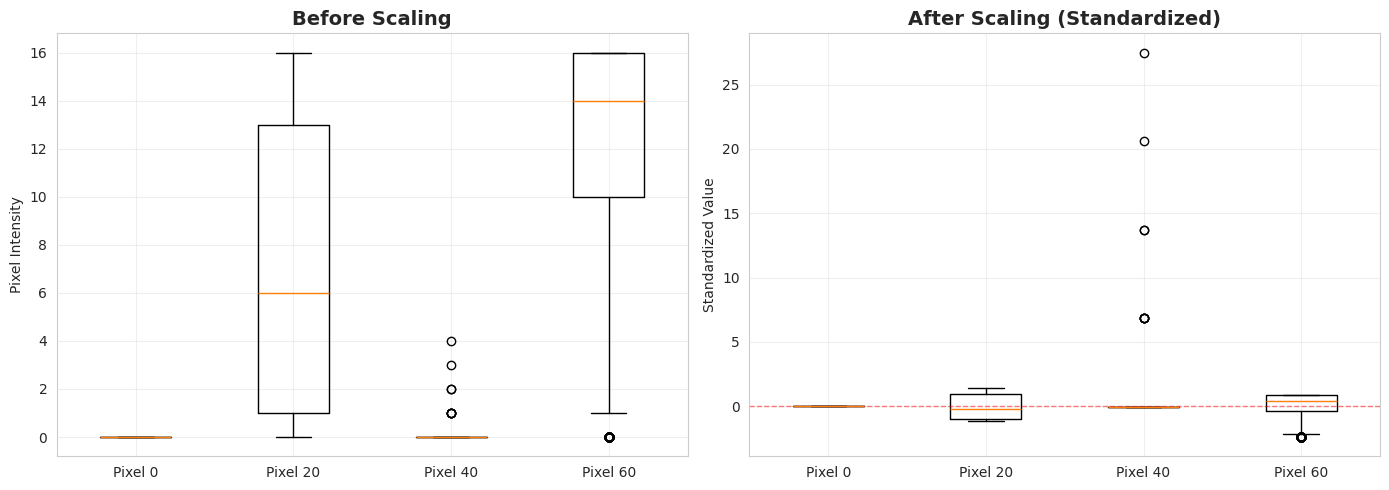

In [ ]:
# Compare a few features before and after scaling
selected_features = [0, 20, 40, 60]
feature_names = [f'Pixel {i}' for i in selected_features]

# Original statistics
print("\nBEFORE SCALING (Original Features):")
print(f"{'Feature':<12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 48)
for idx, name in zip(selected_features, feature_names):
    col = X[:, idx]
    print(f"{name:<12} {col.mean():8.2f} {col.std():8.2f} {col.min():8.2f} {col.max():8.2f}")

# Apply scaling
scaler_demo = StandardScaler()
X_scaled_demo = scaler_demo.fit_transform(X)

# Scaled statistics
print("\nAFTER SCALING (Standardized Features):")
print(f"{'Feature':<12} {'Mean':>8} {'Std':>8} {'Min':>8} {'Max':>8}")
print("-" * 48)
for idx, name in zip(selected_features, feature_names):
    col = X_scaled_demo[:, idx]
    print(f"{name:<12} {col.mean():8.5f} {col.std():8.5f} {col.min():8.2f} {col.max():8.2f}")

print("\n✓ All features now have mean ≈ 0 and std ≈ 1")
print("✓ All features contribute equally to distance calculations")

# Visualize the scaling effect
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot([X[:, idx] for idx in selected_features], tick_labels=feature_names)
axes[0].set_title('Before Scaling', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Pixel Intensity')
axes[0].grid(True, alpha=0.3)

# After scaling
axes[1].boxplot([X_scaled_demo[:, idx] for idx in selected_features], tick_labels=feature_names)
axes[1].set_title('After Scaling (Standardized)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Standardized Value')
axes[1].grid(True, alpha=0.3)
axes[1].axhline(y=0, color='r', linestyle='--', linewidth=1, alpha=0.5)

plt.tight_layout()
plt.show()

### Interpretation of Results

**1. Statistics Output:**
- **Before Scaling**: You can see that different pixels have very different statistics (some might range 0-255, others might be mostly dark). If we used raw data, the distance calculations would be biased towards features with larger numerical ranges.
- **After Scaling**: All selected features now have a Mean very close to $0$ and a Standard Deviation of $1$. This ensures that each pixel contributes equally to the similarity measures.

**2. Boxplot Visualization:**
The plot above visualizes the distribution of values for the selected pixels.

- The **Box** represents the Interquartile Range (IQR), containing the middle 50% of the data (from the 25th to 75th percentile).
- The **Line** inside the box is the Median (50th percentile).
- The **Whiskers** extend to the most extreme data points not considered outliers (typically $1.5 \times IQR$).
- **Outliers** (individual points) are values that fall beyond the whiskers.

Notice how in the *After Scaling* plot, the boxes are all aligned around the red dashed line ($y=0$) and have similar sizes. This confirms that the data is essentially centered and scaled, ready for clustering.

## 4. Build and Train the Clustering Pipeline

Now we'll create a pipeline that combines preprocessing and clustering. We'll use K=10 clusters since we know there are 10 digits (though the algorithm doesn't know this!).

### Pipeline Definition and Training

1. **StandardScaler**: Ensures all features contribute equally
2. **KMeans**: Finds K cluster centers that minimize within-cluster variance

K-Means Parameters:
- `n_clusters=10`: Number of clusters to find
- `random_state=42`: For reproducibility (K-Means has random initialization)
- `n_init=10`: Number of times to run K-Means with different initializations (keeps best result)
- `max_iter=300`: Maximum iterations before stopping

**Important**: We choose K=10 because we know there are 10 digits. In real unsupervised scenarios, choosing K is a challenge we'll address later.

In [ ]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('kmeans', KMeans(
        n_clusters=10,       # We want 10 clusters (one per digit)
        random_state=42,     # For reproducibility
        n_init=10,           # Run 10 times with different initializations
        max_iter=300         # Maximum iterations per run
    ))
])
pipeline

,steps,"[('scaler', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_clusters,10
,init,'k-means++'
,n_init,10
,max_iter,300


We fit the pipeline to the data. This scales the data and performs K-Means clustering.

In [ ]:
pipeline.fit(X)

,steps,"[('scaler', ...), ('kmeans', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,n_clusters,10
,init,'k-means++'
,n_init,10
,max_iter,300


### Training Statistics

Let's examine the clustering results:
- **Inertia**: Sum of squared distances of samples to their closest cluster center. Lower is generally better (tighter clusters), but inertia decreases as K increases, so it must be interpreted with caution.
- **Cluster Sizes**: We check if the clusters are relatively balanced or if some are empty/tiny.

In [ ]:
# Access the trained components
scaler = pipeline.named_steps['scaler']
kmeans = pipeline.named_steps['kmeans']

# Get cluster assignments
labels_pred = kmeans.labels_

print(f"Number of clusters: {kmeans.n_clusters}")
print(f"Number of iterations: {kmeans.n_iter_}")
print(f"Final inertia (sum of squared distances to centers): {kmeans.inertia_:.2f}")

# Show cluster sizes
unique_labels, counts = np.unique(labels_pred, return_counts=True)
for cluster_id, count in zip(unique_labels, counts):
    bar = '█' * (count // 10)
    print(f"Cluster {cluster_id}: {count:3d} samples {bar}")

Number of clusters: 10
Number of iterations: 32
Final inertia (sum of squared distances to centers): 69813.56
Cluster 0: 245 samples ████████████████████████
Cluster 1: 156 samples ███████████████
Cluster 2: 177 samples █████████████████
Cluster 3:  71 samples ███████
Cluster 4: 232 samples ███████████████████████
Cluster 5: 179 samples █████████████████
Cluster 6: 127 samples ████████████
Cluster 7: 183 samples ██████████████████
Cluster 8: 397 samples ███████████████████████████████████████
Cluster 9:  30 samples ███


### Interpretation of Training Results

**1. Iterations**: The algorithm converged in **32 iterations** (well below the default limit of 300).
   - **Convergence Criteria**: K-Means stops iterating when the cluster centers move less than a specific threshold (tolerance `tol=1e-4` by default) between consecutive steps.
   - **Meaning**: Converging in 32 iterations means the centroids stabilized quickly and found a local minimum without needing to be force-stopped by `max_iter`.

**2. Inertia (69,813.56)**: Is this good or bad?
To understand this number, we compare it to the total variation in the dataset:

*   **Total Variance (Total Sum of Squares)**: Since we standardized the data, every feature (pixel) has a variance of $1$. With $1,797$ samples and $64$ features, the maximum possible inertia (if we had just 1 cluster) would be $\approx 1,797 \times 64 = 115,008$.
*   **Inertia (Within-Cluster Variance)**: This is the "noise" or variation left *inside* the clusters. A value of $69,813$ means that $\approx 60\%$ of the total variation is still inside the clusters ($69,813 / 115,008 = 0.607$).
*   **Explained Variance**: The clustering structure explains the remaining $\approx 40\%$ of the variation. This represents how well separated the 10 groups are.

**Conclusion**: Recovering 40% of the structure with just 10 simple centers is reasonable for high-dimensional handwritten digits, where much of the variation comes from individual handwriting styles (slant, thickness) rather than just the digit identity.

**3. Cluster Sizes**: We see that all clusters have a significant number of samples (none are empty). This suggests the algorithm didn't get stuck in a trivial local minimum and found a balanced partition.

### 4.3. Visualizing Cluster Centers

Since we are in a 64-dimensional space, we can visualize the **cluster centers** (centroids) to understand what each cluster represents. 
Because we used `StandardScaler`, the centroids are in the scaled space. We use `scaler.inverse_transform` to map them back to the original pixel intensity space (0-16) and reshape them into 8x8 images.

Ideally, each centroid should look like a clear digit.

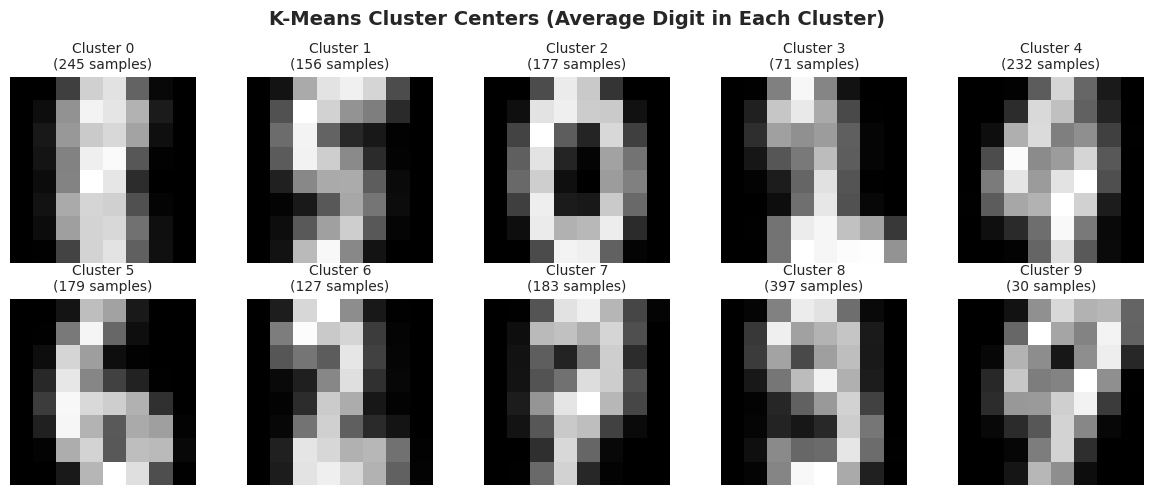

In [ ]:
# Visualize cluster centers as digit images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('K-Means Cluster Centers (Average Digit in Each Cluster)', fontsize=14, fontweight='bold')

# Get cluster centers in original space (inverse transform from scaled space)
centers_scaled = kmeans.cluster_centers_
centers_original = scaler.inverse_transform(centers_scaled)

for i, ax in enumerate(axes.flat):
    # Reshape center to 8x8 image
    center_image = centers_original[i].reshape(8, 8)
    ax.imshow(center_image, cmap='gray')
    ax.set_title(f'Cluster {i}\n({counts[i]} samples)', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

## 5. Evaluate Clustering Performance

Evaluating clustering is tricky because we don't have "correct" labels in true unsupervised scenarios. However, since we have true digit labels, we can use both **unsupervised** and **supervised** metrics.

### Unsupervised Metrics (Ignoring True Labels)

These metrics evaluate cluster quality based solely on the geometry of clusters:

**Silhouette Score** (-1 to 1, higher is better):
- Measures how similar points are to their own cluster vs. other clusters
- Formula: $s = \frac{b - a}{\max(a, b)}$ where $a$ = avg distance to own cluster, $b$ = avg distance to nearest other cluster

**Calinski-Harabasz Score** (higher is better):
- Ratio of between-cluster dispersion to within-cluster dispersion
- Higher means clusters are dense and well-separated

**Davies-Bouldin Score** (lower is better):
- Average similarity between each cluster and its most similar cluster
- Lower means better separation

In [ ]:
# Get scaled data for evaluation
X_scaled = scaler.transform(X)

# Compute unsupervised metrics
silhouette = silhouette_score(X_scaled, labels_pred)
calinski_harabasz = calinski_harabasz_score(X_scaled, labels_pred)
davies_bouldin = davies_bouldin_score(X_scaled, labels_pred)

print("\nThese metrics evaluate cluster quality without using true labels:\n")
print(f"Silhouette Score:        {silhouette:8.4f}  (Range: [-1, 1], higher is better)")
print(f"Calinski-Harabasz Score: {calinski_harabasz:8.2f}  (Higher is better)")
print(f"Davies-Bouldin Score:    {davies_bouldin:8.4f}  (Lower is better)")

# Interpret silhouette score
if silhouette > 0.5:
    interpretation = "Good cluster separation"
elif silhouette > 0.25:
    interpretation = "Moderate cluster structure"
else:
    interpretation = "Weak cluster structure"
print(f"\nSilhouette interpretation: {interpretation}")



These metrics evaluate cluster quality without using true labels:

Silhouette Score:          0.1394  (Range: [-1, 1], higher is better)
Calinski-Harabasz Score:   113.20  (Higher is better)
Davies-Bouldin Score:      1.8770  (Lower is better)

Silhouette interpretation: Weak cluster structure


### Supervised Metrics (Use True Labels for Comparison)

**Important**: In real-world unsupervised clustering, we lack true labels and rely on intrinsic metrics (like Silhouette). We use external metrics (ARI, NMI) here for **benchmarking** purposes since the ground truth is available for this dataset.\n

These measure agreement between predicted clusters and true labels:

**Adjusted Rand Index** (-1 to 1, higher is better):
- Measures similarity between two clusterings, adjusted for chance
- 1 = perfect match, 0 = random, < 0 = worse than random

**Normalized Mutual Information** (0 to 1, higher is better):
- Measures mutual information between cluster labels and true labels

**Homogeneity, Completeness, V-Measure**:
- Homogeneity: Each cluster contains only members of a single class
- Completeness: All members of a class are in the same cluster
- V-Measure: Harmonic mean of homogeneity and completeness

In [ ]:
# Compute supervised metrics (comparing with true labels)
ari = adjusted_rand_score(y_true, labels_pred)
nmi = normalized_mutual_info_score(y_true, labels_pred)
homogeneity = homogeneity_score(y_true, labels_pred)
completeness = completeness_score(y_true, labels_pred)
v_measure = v_measure_score(y_true, labels_pred)

print(f"Adjusted Rand Index (ARI):      {ari:8.4f}  (Range: [-1, 1], higher is better)")
print(f"Normalized Mutual Info (NMI):   {nmi:8.4f}  (Range: [0, 1], higher is better)")
print(f"Homogeneity:                    {homogeneity:8.4f}  (Each cluster = one digit)")
print(f"Completeness:                   {completeness:8.4f}  (Each digit = one cluster)")
print(f"V-Measure:                      {v_measure:8.4f}  (Harmonic mean)")

Adjusted Rand Index (ARI):        0.5344  (Range: [-1, 1], higher is better)
Normalized Mutual Info (NMI):     0.6712  (Range: [0, 1], higher is better)
Homogeneity:                      0.6498  (Each cluster = one digit)
Completeness:                     0.6941  (Each digit = one cluster)
V-Measure:                        0.6712  (Harmonic mean)


Create a mapping from clusters to digits (which digit is most common in each cluster?)

In [ ]:
print(f"✓ Clusters have {v_measure*100:.1f}% agreement with true digit labels")
print(f"✓ Average silhouette score of {silhouette:.3f} indicates reasonably separated clusters")

✓ Clusters have 67.1% agreement with true digit labels
✓ Average silhouette score of 0.139 indicates reasonably separated clusters


In [ ]:
cluster_to_digit = {}
for cluster_id in range(10):
    # Get all true labels for this cluster
    mask = labels_pred == cluster_id
    true_labels_in_cluster = y_true[mask]
    
    # Find most common digit
    unique, counts = np.unique(true_labels_in_cluster, return_counts=True)
    most_common_digit = unique[np.argmax(counts)]
    purity = counts[np.argmax(counts)] / len(true_labels_in_cluster) * 100
    
    cluster_to_digit[cluster_id] = most_common_digit
    
    print(f"Cluster {cluster_id} → Digit {most_common_digit} (Purity: {purity:.1f}%)")
    
    # Show distribution of all digits in this cluster
    dist = " | ".join([f"{d}:{cnt}" for d, cnt in zip(unique, counts)])
    print(f"            Distribution: {dist}\n")

Cluster 0 → Digit 1 (Purity: 43.7%)
            Distribution: 1:107 | 2:21 | 3:7 | 4:1 | 5:1 | 6:5 | 8:101 | 9:2

Cluster 1 → Digit 5 (Purity: 87.8%)
            Distribution: 1:1 | 3:3 | 4:2 | 5:137 | 7:1 | 8:7 | 9:5

Cluster 2 → Digit 0 (Purity: 99.4%)
            Distribution: 0:176 | 6:1

Cluster 3 → Digit 2 (Purity: 60.6%)
            Distribution: 1:27 | 2:43 | 3:1

Cluster 4 → Digit 4 (Purity: 68.5%)
            Distribution: 0:2 | 1:46 | 2:3 | 4:159 | 5:2 | 7:2 | 8:3 | 9:15

Cluster 5 → Digit 6 (Purity: 97.8%)
            Distribution: 5:2 | 6:175 | 8:2

Cluster 6 → Digit 2 (Purity: 81.9%)
            Distribution: 2:104 | 3:9 | 7:7 | 8:7

Cluster 7 → Digit 7 (Purity: 83.1%)
            Distribution: 2:1 | 3:7 | 4:10 | 7:152 | 8:4 | 9:9

Cluster 8 → Digit 3 (Purity: 39.3%)
            Distribution: 1:1 | 2:5 | 3:156 | 5:40 | 8:50 | 9:145

Cluster 9 → Digit 7 (Purity: 56.7%)
            Distribution: 4:9 | 7:17 | 9:4



## 6. Visualize Clustering Results

Since our data has 64 dimensions, we can't directly visualize it. We'll use **PCA** (Principal Component Analysis) to reduce it to 2D for visualization.

### What is PCA?

PCA finds the directions (principal components) in which the data varies most. By projecting data onto the first 2-3 components, we can visualize high-dimensional data while preserving most of the variance.

**Important**: This is just for visualization. The actual clustering was performed in the full 64-dimensional space.

### Visualization & Analysis

#### 1. PCA Projection (Left & Middle)
- Points close together in 2D were also close in 64D space
- Some overlap is expected - we lost information projecting 64D → 2D
- Compare predicted clusters vs true labels to see agreement



Reduced 64 dimensions to 2 principal components
Variance explained by PC1: 12.03%
Variance explained by PC2: 9.56%
Total variance explained: 21.59%


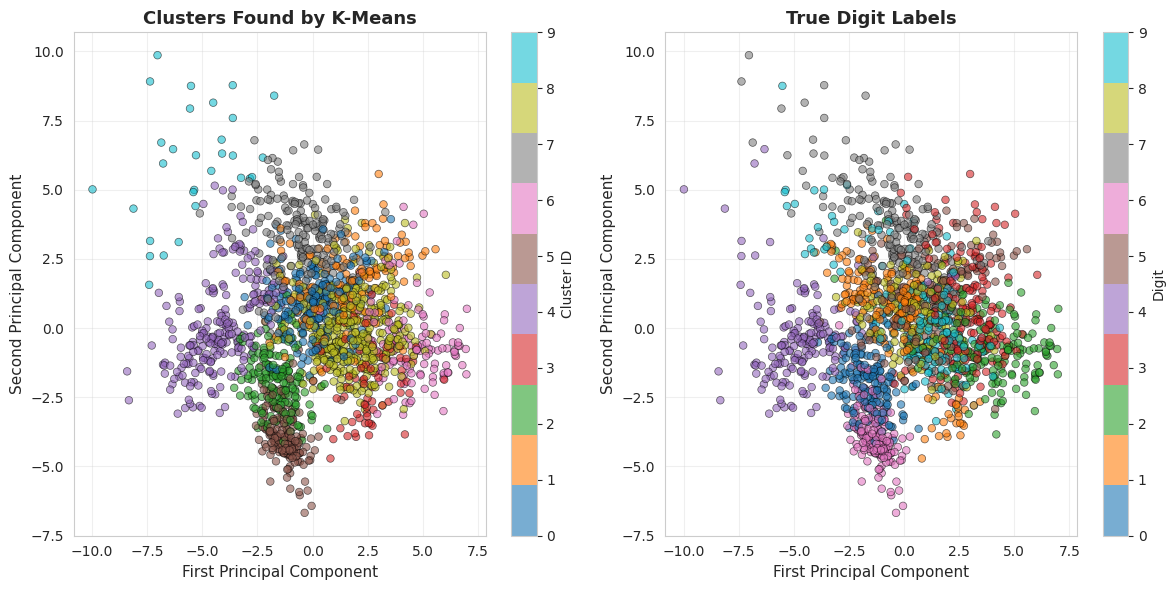

In [ ]:
# Apply PCA to reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print(f"\nReduced {X.shape[1]} dimensions to 2 principal components")
print(f"Variance explained by PC1: {pca.explained_variance_ratio_[0]*100:.2f}%")
print(f"Variance explained by PC2: {pca.explained_variance_ratio_[1]*100:.2f}%")
print(f"Total variance explained: {sum(pca.explained_variance_ratio_)*100:.2f}%")

# Create visualization for Clusters vs True Labels
fig = plt.figure(figsize=(12, 6))

# Plot 1: Colored by predicted cluster
ax1 = fig.add_subplot(121)
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=labels_pred, 
                       cmap='tab10', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
ax1.set_xlabel('First Principal Component', fontsize=11)
ax1.set_ylabel('Second Principal Component', fontsize=11)
ax1.set_title('Clusters Found by K-Means', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3)
cbar1 = plt.colorbar(scatter1, ax=ax1, ticks=range(10))
cbar1.set_label('Cluster ID', fontsize=10)

# Plot 2: Colored by true digit
ax2 = fig.add_subplot(122)
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=y_true, 
                       cmap='tab10', alpha=0.6, s=30, edgecolors='k', linewidth=0.5)
ax2.set_xlabel('First Principal Component', fontsize=11)
ax2.set_ylabel('Second Principal Component', fontsize=11)
ax2.set_title('True Digit Labels', fontsize=13, fontweight='bold')
ax2.grid(True, alpha=0.3)
cbar2 = plt.colorbar(scatter2, ax=ax2, ticks=range(10))
cbar2.set_label('Digit', fontsize=10)

plt.tight_layout()
plt.show()


#### 2. Silhouette Plot (Right)
- Each horizontal bar = one sample, sorted by silhouette coefficient
- Wider bars above red line = well-clustered
- Thin or negative bars = possibly misclassified
- All clusters have positive average silhouette scores ✓

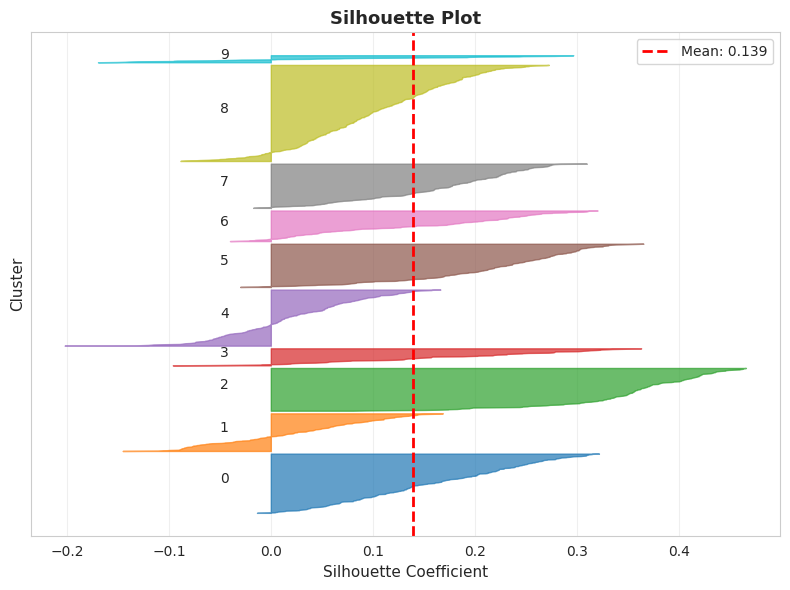

In [ ]:
# Plot 3: Silhouette analysis
fig = plt.figure(figsize=(8, 6))
ax3 = fig.add_subplot(111)
silhouette_vals = silhouette_samples(X_scaled, labels_pred)
y_lower = 10

for i in range(10):
    cluster_silhouette_vals = silhouette_vals[labels_pred == i]
    cluster_silhouette_vals.sort()
    
    size_cluster_i = cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.tab10(i / 10)
    ax3.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_silhouette_vals,
                      facecolor=color, edgecolor=color, alpha=0.7)
    
    ax3.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

ax3.set_xlabel('Silhouette Coefficient', fontsize=11)
ax3.set_ylabel('Cluster', fontsize=11)
ax3.set_title('Silhouette Plot', fontsize=13, fontweight='bold')
ax3.axvline(x=silhouette, color="red", linestyle="--", linewidth=2, label=f'Mean: {silhouette:.3f}')
ax3.set_yticks([])
ax3.legend()
ax3.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()


#### 3. Sample Images
- Shows actual digit images from each cluster
- Most clusters contain predominantly one digit type
- Some confusion between similar-looking digits (e.g., 3 and 8, 4 and 9)


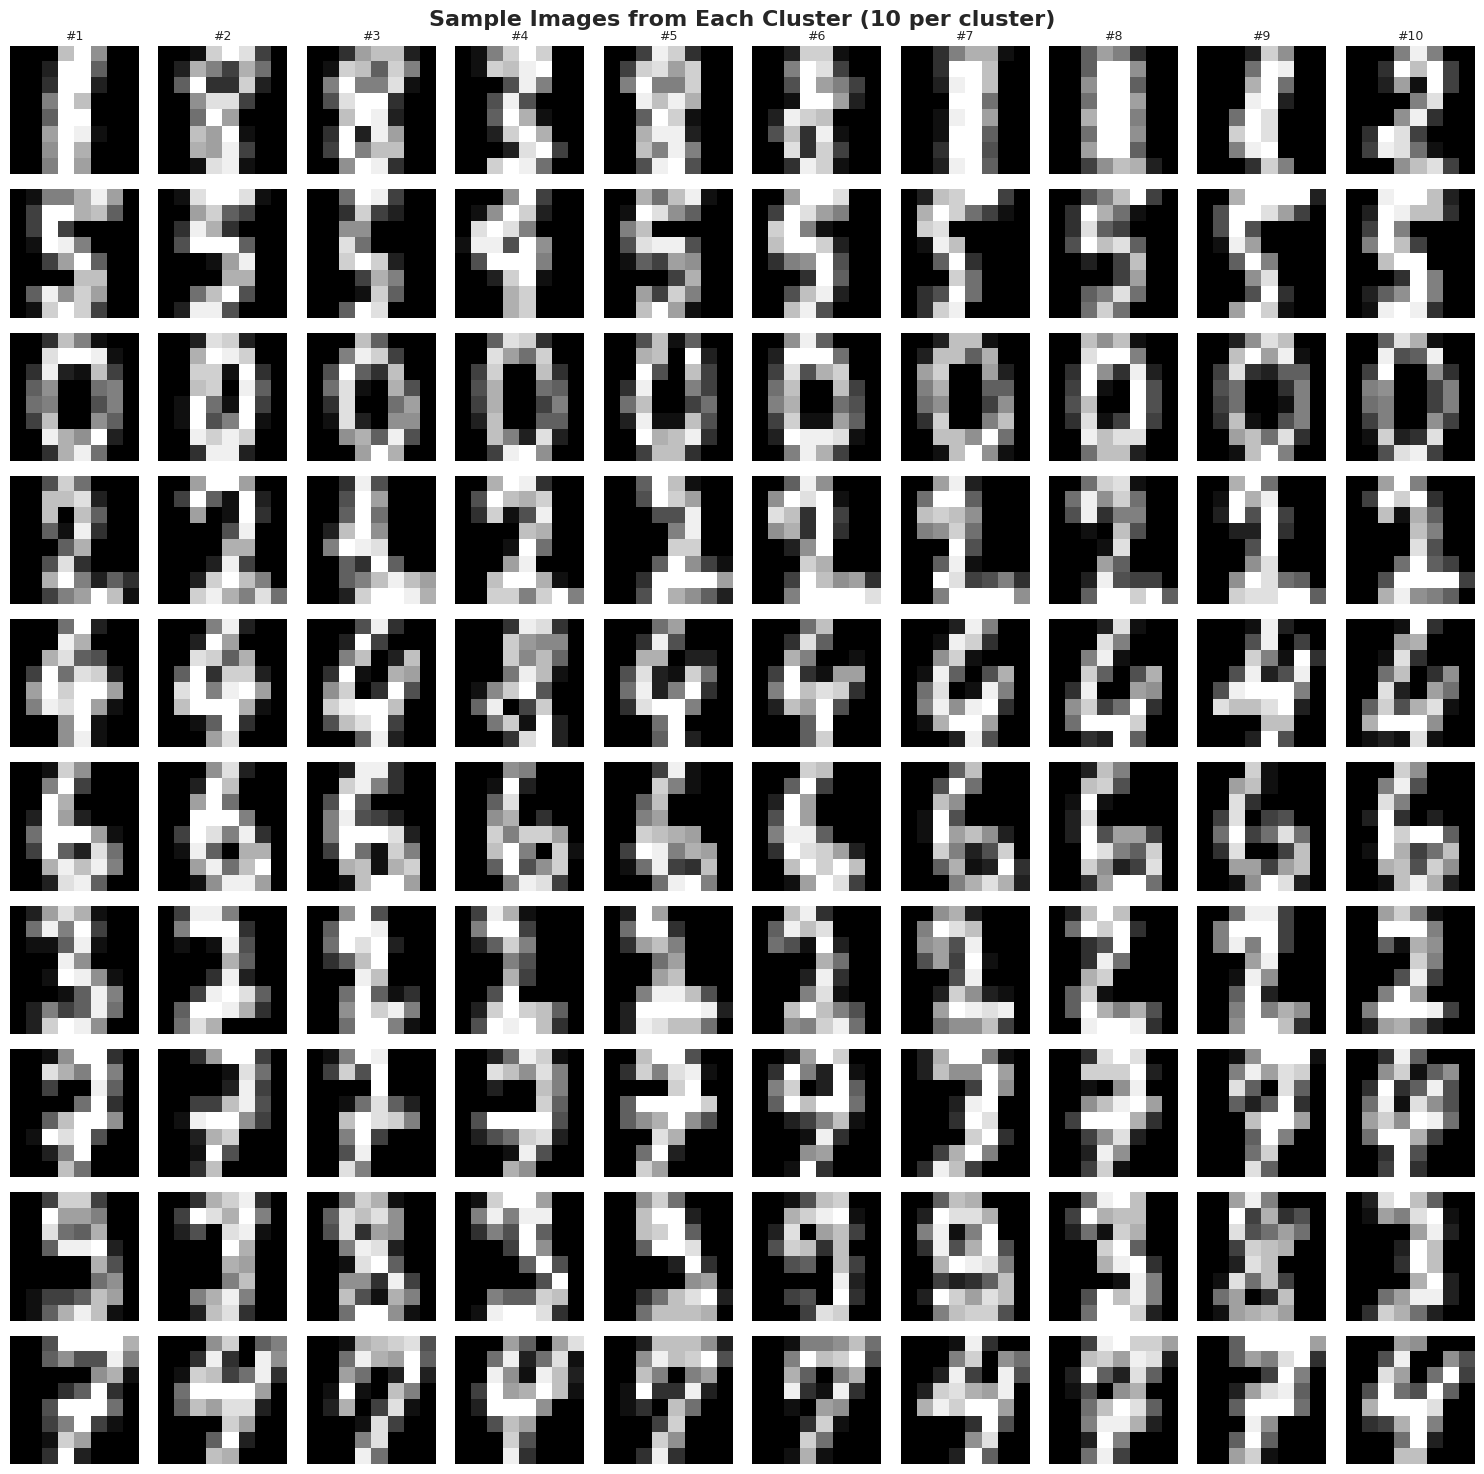

In [ ]:
# Show sample images from each cluster
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
fig.suptitle('Sample Images from Each Cluster (10 per cluster)', fontsize=16, fontweight='bold')

for cluster_id in range(10):
    # Get indices of images in this cluster
    cluster_indices = np.where(labels_pred == cluster_id)[0]
    
    # Sample up to 10 images
    sample_indices = np.random.choice(cluster_indices, min(10, len(cluster_indices)), replace=False)
    
    for i, img_idx in enumerate(sample_indices):
        ax = axes[cluster_id, i]
        image = X[img_idx].reshape(8, 8)
        ax.imshow(image, cmap='gray')
        ax.axis('off')
        
        if i == 0:
            # Map cluster to most common digit
            most_common = cluster_to_digit[cluster_id]
            ax.set_ylabel(f'Cluster {cluster_id}\n(→Digit {most_common})', 
                         fontsize=10, fontweight='bold')
        
        # Add column labels on the top row
        if cluster_id == 0:
            ax.set_title(f'#{i+1}', fontsize=9, pad=5)

plt.tight_layout()
plt.show()


## 7. Choosing the Number of Clusters (K)

In our example, we knew K=10 because there are 10 digits. But what if we didn't know? Let's explore methods for choosing K.

### The Elbow Method

Plot the **inertia** (sum of squared distances to cluster centers) for different values of K. Look for an "elbow" where the rate of decrease sharply changes.

### Silhouette Method

Plot the silhouette score for different K values. Choose K that maximizes the silhouette score.

Let's try both methods:


This may take a minute...

K= 2 | Inertia: 100,423.84 | Silhouette: 0.1056
K= 3 | Inertia:  93,842.48 | Silhouette: 0.1053
K= 4 | Inertia:  89,213.97 | Silhouette: 0.0954
K= 5 | Inertia:  85,096.05 | Silhouette: 0.1023
K= 6 | Inertia:  81,678.47 | Silhouette: 0.0988
K= 7 | Inertia:  77,749.33 | Silhouette: 0.1135
K= 8 | Inertia:  74,854.16 | Silhouette: 0.1266
K= 9 | Inertia:  72,029.73 | Silhouette: 0.1360
K=10 | Inertia:  69,813.56 | Silhouette: 0.1394
K=11 | Inertia:  67,261.85 | Silhouette: 0.1532
K=12 | Inertia:  65,031.72 | Silhouette: 0.1543
K=13 | Inertia:  62,763.18 | Silhouette: 0.1565
K=14 | Inertia:  61,963.42 | Silhouette: 0.1562
K=15 | Inertia:  59,534.50 | Silhouette: 0.1583
K=16 | Inertia:  59,448.73 | Silhouette: 0.1520
K=17 | Inertia:  57,038.16 | Silhouette: 0.1497
K=18 | Inertia:  57,000.79 | Silhouette: 0.1555
K=19 | Inertia:  55,043.49 | Silhouette: 0.1568
K=20 | Inertia:  54,099.96 | Silhouette: 0.1579

✓ Evaluation complete!


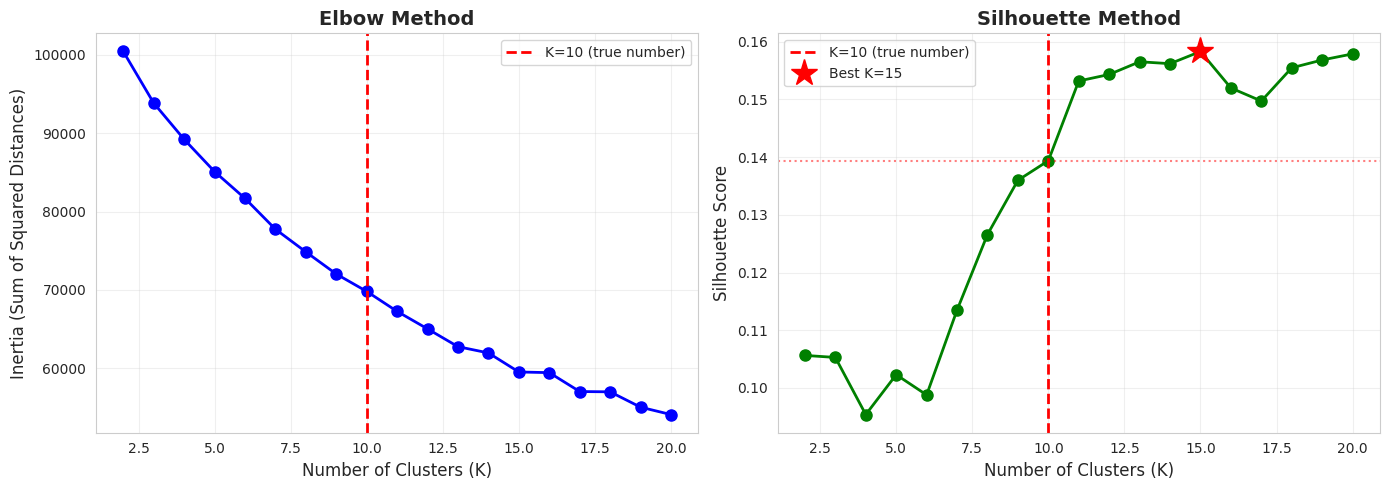



Best K by silhouette score: 15
True number of digits: 10

Elbow method:
  Look for where the curve 'bends' - rate of decrease slows
  Elbow appears around K=8-10

Silhouette method:
  Maximum silhouette at K=15: 0.1583
  Silhouette at K=10: 0.1394

✓ Both methods suggest K around 8-12, confirming our choice of K=10!


In [ ]:
# Test different numbers of clusters
K_range = range(2, 21)
inertias = []
silhouettes = []

print("=" * 80)
print("=" * 80)
print("\nThis may take a minute...\n")

for k in K_range:
    # Create pipeline with k clusters
    pipeline_k = Pipeline([
        ('scaler', StandardScaler()),
        ('kmeans', KMeans(n_clusters=k, random_state=42, n_init=10))
    ])
    
    # Fit and evaluate
    pipeline_k.fit(X)
    labels_k = pipeline_k.named_steps['kmeans'].labels_
    X_scaled_k = pipeline_k.named_steps['scaler'].transform(X)
    
    inertias.append(pipeline_k.named_steps['kmeans'].inertia_)
    silhouettes.append(silhouette_score(X_scaled_k, labels_k))
    
    print(f"K={k:2d} | Inertia: {inertias[-1]:10,.2f} | Silhouette: {silhouettes[-1]:.4f}")

print("\n✓ Evaluation complete!")

# Visualize results
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=10, color='r', linestyle='--', linewidth=2, label='K=10 (true number)')
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Inertia (Sum of Squared Distances)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# Silhouette plot
axes[1].plot(K_range, silhouettes, 'go-', linewidth=2, markersize=8)
axes[1].axvline(x=10, color='r', linestyle='--', linewidth=2, label='K=10 (true number)')
axes[1].axhline(y=silhouettes[K_range.index(10)], color='r', linestyle=':', alpha=0.5)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Method', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)
axes[1].legend()

# Mark the maximum silhouette score
best_k = K_range[np.argmax(silhouettes)]
axes[1].plot(best_k, max(silhouettes), 'r*', markersize=20, label=f'Best K={best_k}')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n" + "=" * 80)
print("=" * 80)
print(f"\nBest K by silhouette score: {best_k}")
print(f"True number of digits: 10")
print(f"\nElbow method:")
print("  Look for where the curve 'bends' - rate of decrease slows")
print(f"  Elbow appears around K=8-10")
print(f"\nSilhouette method:")
print(f"  Maximum silhouette at K={best_k}: {max(silhouettes):.4f}")
print(f"  Silhouette at K=10: {silhouettes[K_range.index(10)]:.4f}")

print("\n✓ Both methods suggest K around 8-12, confirming our choice of K=10!")

## 8. Key Takeaways

### What We Learned

1. **Unsupervised Learning**: K-Means discovered digit groupings without ever seeing labels, achieving significant agreement with true classes.

2. **Feature Scaling is Critical**: K-Means uses Euclidean distance, so features must be on comparable scales. StandardScaler ensures equal contribution from all features.

3. **Pipelines for Clustering**: Even though clustering is unsupervised, pipelines still provide benefits: clean code, no data leakage in preprocessing, and easy experimentation.

4. **Multiple Evaluation Metrics**: Used both unsupervised metrics (silhouette, inertia) and supervised metrics (ARI, NMI) to understand performance from different angles.

5. **Choosing K is Hard**: In real scenarios without true labels, use elbow method, silhouette analysis, and domain knowledge to select K.

### Limitations of K-Means

1. **Must specify K**: Need to know or guess the number of clusters
2. **Assumes spherical clusters**: Struggles with elongated or irregular shapes
3. **Sensitive to initialization**: Different random starts can give different results (mitigated by `n_init`)
4. **Sensitive to outliers**: Outliers can distort cluster centers
5. **Equal variance assumption**: Assumes clusters have similar sizes and densities

### When to Use K-Means

**Good for:**
- Large datasets (efficient algorithm)
- Roughly spherical, well-separated clusters
- When you have a reasonable estimate for K
- Initial exploratory analysis

**Consider alternatives for:**
- Unknown number of clusters → Try DBSCAN or Hierarchical Clustering
- Non-spherical clusters → Try DBSCAN or Spectral Clustering
- Different cluster densities → Try DBSCAN
- Outlier sensitivity → Try DBSCAN or robust variations

### Best Practices Demonstrated

✓ Always scale features before K-Means  
✓ Use pipelines to ensure consistent preprocessing  
✓ Try multiple values of K and compare metrics  
✓ Visualize results (even high-dimensional data via PCA)  
✓ Use multiple evaluation metrics  
✓ Examine cluster contents to verify meaningful groupings  
✓ Set random_state for reproducibility  
✓ Use n_init > 1 to find best initialization